In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

In [5]:
dataset_train = pd.read_csv('Google_Stock_Price_Train.csv')
training_set = dataset_train.iloc[:, 1:2].values 

In [7]:
sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(training_set)


In [9]:
X_train = []
y_train = []

for i in range(60, len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

# Reshape for LSTM [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [11]:
model = Sequential()

# Layer 1
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

# Layer 2
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

# Layer 3
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

# Layer 4
model.add(LSTM(units=50))
model.add(Dropout(0.2))

# Output layer
model.add(Dense(units=1))

# Compile model
model.compile(optimizer='adam', loss='mean_squared_error')

C:\Users\sai\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.fit(X_train, y_train, epochs=25, batch_size=32)

Epoch 1/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - loss: 0.0297
Epoch 2/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - loss: 0.0070
Epoch 3/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.0051
Epoch 4/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 0.0049
Epoch 5/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.0054
Epoch 6/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0048
Epoch 7/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.0049
Epoch 8/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.0047
Epoch 9/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 0.0044
Epoch 10/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.0039
Epoch 11/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.0040
Epoch 12/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.0045
Epoch 13/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.0040
Epoch 14/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.0039
Epoch 15/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.0041
Epoc

In [15]:
dataset_test = pd.read_csv('Google_Stock_Price_Test.csv')
real_stock_price = dataset_test.iloc[:, 1:2].values

In [17]:
dataset_total = pd.concat((dataset_train['Open'], dataset_test['Open']), axis=0)

inputs = dataset_total[len(dataset_total) - len(dataset_test) - 60:].values
inputs = inputs.reshape(-1, 1)

inputs = sc.transform(inputs)

In [19]:

X_test = []

for i in range(60, len(inputs)):
    X_test.append(inputs[i-60:i, 0])

X_test = np.array(X_test)

X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))


In [21]:
predicted_stock_price = model.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 710ms/step


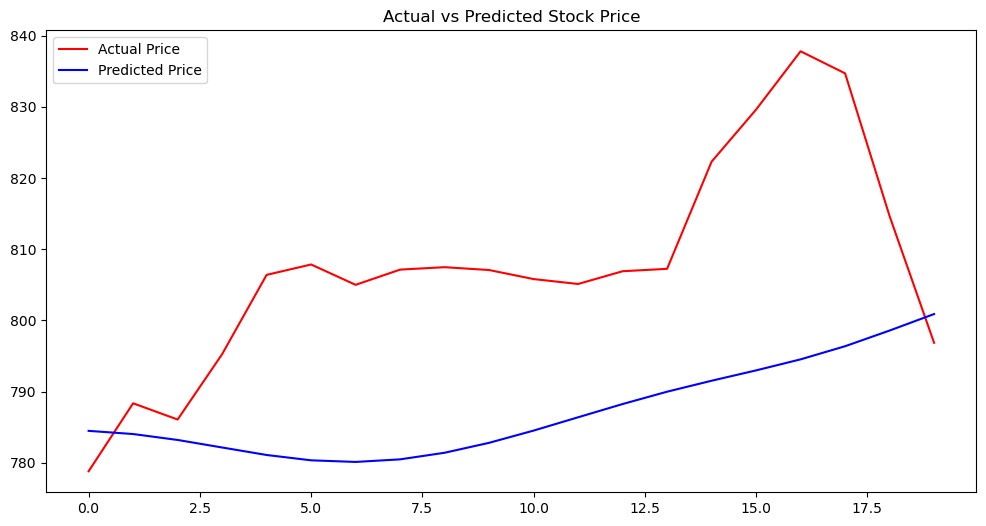

In [35]:
plt.figure(figsize=(12,6))
plt.plot(real_stock_price, color='red', label='Actual Price')
plt.plot(predicted_stock_price, color='blue', label='Predicted Price')
plt.title("Actual vs Predicted Stock Price")
plt.legend()
plt.show()

In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
# RMSE
rmse = np.sqrt(mean_squared_error(real_stock_price, predicted_stock_price))
print("RMSE:", rmse)

# MAE
mae = mean_absolute_error(real_stock_price, predicted_stock_price)
print("MAE:", mae)

# MAPE
mape = np.mean(np.abs((real_stock_price - predicted_stock_price) / real_stock_price)) * 100
print("MAPE:", mape, "%")
accuracy = 100 - mape
print("Model Accuracy:", accuracy, "%")

RMSE: 24.064812929967935
MAE: 21.286349853515624
MAPE: 2.6138151158807843 %
Model Accuracy: 97.38618488411922 %


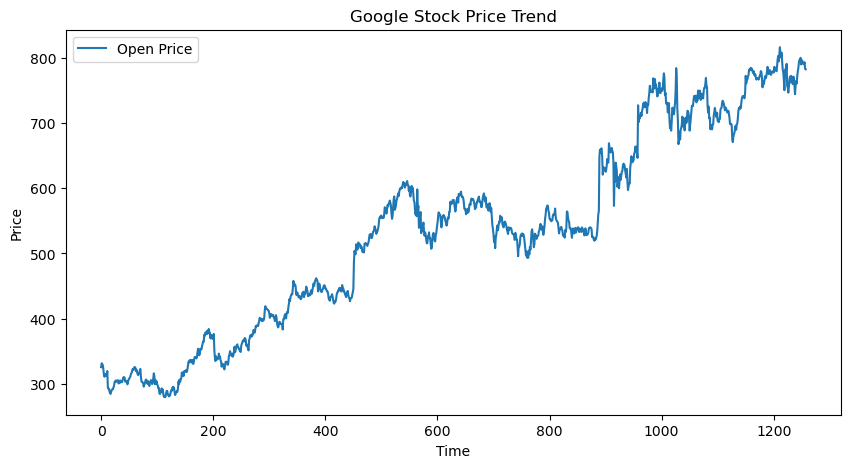

In [33]:
plt.figure(figsize=(10,5))
plt.plot(dataset_train['Open'], label='Open Price')
plt.title("Google Stock Price Trend")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

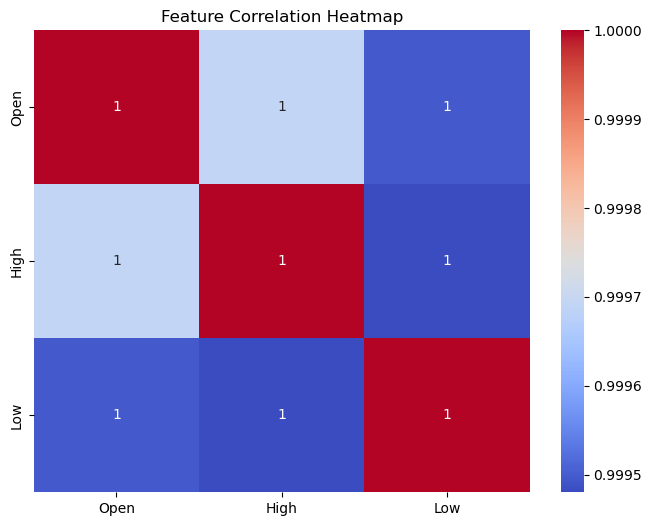

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_data = dataset_train.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()